## Loading OPENAI API KEY

In [3]:
%load_ext dotenv
%dotenv

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [2]:
import os
for key,value in os.environ.items():
    #print(key,value)
    if key == 'OPENAI_API_KEY': 
        #print(key,value)
        print('')

## Creating a state node and chatbot node to invoke state

In [3]:
from langgraph.graph import START,END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage,BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

/opt/anaconda3/envs/langgraph_env/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
class State(TypedDict):
    messages = Sequence[BaseMessage]
#instance of state
state = State(messages =[HumanMessage('Can you suggest a list of outdoor flowering plants? ')] )

In [5]:
model = ChatOpenAI(model  ='gpt-5.4-mini', temperature = 0, seed = 100, max_completion_tokens = 100)

In [6]:
response = model.invoke(state['messages'])

In [7]:
response

AIMessage(content='Sure — here’s a solid list of outdoor flowering plants, including a mix of annuals, perennials, shrubs, and climbers:\n\n### Annuals\n- **Marigold** – bright, easy to grow, blooms all season\n- **Petunia** – colorful and great for beds or hanging baskets\n- **Zinnia** – sun-loving and long-blooming\n- **Impatiens** – good for shady areas\n- **Cosmos** –', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 17, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoE4lc5bt4LOHmLQJhMBubCvnAIsP', 'service_tier': 'default', 'finish_reason': 'length', 'logprobs': None}, id='run--019ea3b3-05f6-79b3-b93e-af248f135250-0', usage_metadata={'input_tokens': 17, '

In [8]:
type(response).__bases__

(langchain_core.messages.base.BaseMessage,)

In [9]:
def chatbot(state: State) -> State:
    print('Entering Chatbot')
    response = model.invoke(state["messages"])
    response.pretty_print()
    return State(messages = [response])

In [10]:
resp = chatbot(state)

Entering Chatbot
================================== Ai Message ==================================

Sure — here’s a solid list of outdoor flowering plants, including a mix of annuals, perennials, shrubs, and climbers:

### Annuals
- **Petunias** – colorful, long-blooming, great for beds and containers
- **Marigolds** – hardy, bright, and easy to grow
- **Zinnias** – heat-tolerant with bold flowers
- **Impatiens** – excellent for shady spots
- **


## Define state, model node,compile, and execute graph

In [11]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

In [12]:
### define schema of node
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [13]:
model = ChatOpenAI(model  ='gpt-5.4-mini', temperature = 0, seed = 100, max_completion_tokens = 100)

#function_node
def chatbot(state: State) -> State:
    print('Entering Chatbot')
    response = model.invoke(state["messages"])
    response.pretty_print()
    return State(messages = [response])

### Define graph

In [14]:
##START -> CHATBOT -> END
graph = StateGraph(State)
graph.add_node("chatbot",chatbot)
graph.add_edge(START,"chatbot")
graph.add_edge("chatbot",END)

In [17]:
graph_compiled = graph.compile()
print(isinstance(graph,Runnable))
print(isinstance(graph_compiled,Runnable))

False
True


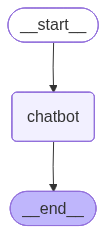

In [18]:
graph_compiled

### Test Graph

In [19]:
input_state = State(messages = [HumanMessage('Can you suggest a list of outdoor flowering plants? ')])
graph_compiled.invoke(input_state)

Entering Chatbot
================================== Ai Message ==================================

Sure — here’s a solid list of outdoor flowering plants, including a mix of annuals, perennials, shrubs, and climbers:

### Annuals
- **Marigold** – bright, easy to grow, blooms most of the season
- **Petunia** – colorful, great for beds and containers
- **Zinnia** – sun-loving and long-blooming
- **Geranium** – classic bedding plant with vibrant flowers
- **Cosmos


{'messages': [AIMessage(content='Sure — here’s a solid list of outdoor flowering plants, including a mix of annuals, perennials, shrubs, and climbers:\n\n### Annuals\n- **Marigold** – bright, easy to grow, blooms most of the season\n- **Petunia** – colorful, great for beds and containers\n- **Zinnia** – sun-loving and long-blooming\n- **Geranium** – classic bedding plant with vibrant flowers\n- **Cosmos', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 17, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoE571WkBiClydnSknIjLwGOCzjc4', 'service_tier': 'default', 'finish_reason': 'length', 'logprobs': None}, id='run--019ea3b3-59bc-7602-9acd-86e0413c59e0-0', usage

## conditional nodes graph (option 1) - Does not show condition when printing the graph

In [52]:
from typing import Literal

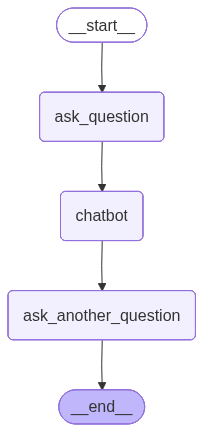

In [63]:
## START -> ASK QUESTION > CHATBOT -> ASK ANOTHER QUESTION ? (YES/NO) 
## YES -> TAKES YOU BACK TO FIRST QUESTION NODE
## NO -> TAKES YOU TO THE END

def ask_question(state:State) -> State:
    print('Entered ask_question node')
    print('Ask a question: ')
    return State(messages = [HumanMessage(content = input())])

def ask_another_question(state:State) -> State:
    print('Entered ask_another_question node')
    print('Do you have another question (yes/no)?: ')
    return State(messages = [HumanMessage(input())])

def routing_function(state:State) -> str:
    print('Entered routing_function node with value: ', state["messages"][0])
    if state["messages"][0].content == "yes":
        return "ask_question"
    return "__end__"
    
graph = StateGraph(State)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("ask_another_question",ask_another_question)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", path = routing_function)

graph_compiled = graph.compile()
graph_compiled

In [65]:

dummy = State(messages = [])
graph_compiled.invoke(State(messages = []))

Entered ask_question node
Ask a question: 


 1 + 1


Entering Chatbot
================================== Ai Message ==================================

2
Entered ask_another_question node
Do you have another question (yes/no)?: 


 yes


Entered routing_function node with value:  content='yes' additional_kwargs={} response_metadata={}
Entered ask_question node
Ask a question: 


 1 + 2


Entering Chatbot
================================== Ai Message ==================================

3
Entered ask_another_question node
Do you have another question (yes/no)?: 


 no


Entered routing_function node with value:  content='no' additional_kwargs={} response_metadata={}


{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}

### conditional graph (option 2) show the condition printing the graph without true or false

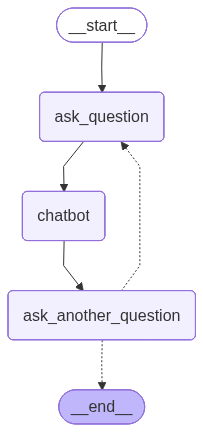

In [66]:
## START -> ASK QUESTION > CHATBOT -> ASK ANOTHER QUESTION ? (YES/NO) 
## YES -> TAKES YOU BACK TO FIRST QUESTION NODE
## NO -> TAKES YOU TO THE END

def ask_question(state:State) -> State:
    print('Entered ask_question node')
    print('Ask a question: ')
    return State(messages = [HumanMessage(content = input())])

def ask_another_question(state:State) -> State:
    print('Entered ask_another_question node')
    print('Do you have another question (yes/no)?: ')
    return State(messages = [HumanMessage(input())])

def routing_function(state:State) -> Literal["ask_question", "__end__"]: ##add this option to show that
    print('Entered routing_function node with value: ', state["messages"][0])
    if state["messages"][0].content == "yes":
        return "ask_question"
    return "__end__"
    
graph = StateGraph(State)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("ask_another_question",ask_another_question)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", path = routing_function)

graph_compiled = graph.compile()
graph_compiled

In [67]:

dummy = State(messages = [])
graph_compiled.invoke(State(messages = []))

Entered ask_question node
Ask a question: 


 1 + 1


Entering Chatbot
================================== Ai Message ==================================

2
Entered ask_another_question node
Do you have another question (yes/no)?: 


 yes


Entered routing_function node with value:  content='yes' additional_kwargs={} response_metadata={}
Entered ask_question node
Ask a question: 


 1 * 3


Entering Chatbot
================================== Ai Message ==================================

3
Entered ask_another_question node
Do you have another question (yes/no)?: 


 no


Entered routing_function node with value:  content='no' additional_kwargs={} response_metadata={}


{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}

### conditional graph (option 3) show the condition printing the graph with true or false

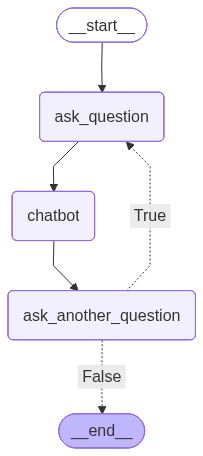

In [75]:
## START -> ASK QUESTION > CHATBOT -> ASK ANOTHER QUESTION ? (YES/NO) 
## YES -> TAKES YOU BACK TO FIRST QUESTION NODE
## NO -> TAKES YOU TO THE END

def ask_question(state:State) -> State:
    print('Entered ask_question node')
    print('Ask a question: ')
    return State(messages = [HumanMessage(content = input())])

def ask_another_question(state:State) -> State:
    print('Entered ask_another_question node')
    print('Do you have another question (yes/no)?: ')
    return State(messages = [HumanMessage(input())])

def routing_function(state:State) -> str:  ##keep this option as same
    print('Entered routing_function node with value: ', state["messages"][0])
    if state["messages"][0].content == "yes":
        return "True"   #routing function returns true or false
    return "False"
    
graph = StateGraph(State)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("ask_another_question",ask_another_question)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
#to show the graph with conditional nodes printed show method like below - based on what routing function returns the corresponding node is selected
graph.add_conditional_edges(source = "ask_another_question", path = routing_function, path_map = {"True": "ask_question", "False": "__end__"})

graph_compiled = graph.compile()
graph_compiled

In [76]:
dummy = State(messages = [])
graph_compiled.invoke(State(messages = []))

Entered ask_question node
Ask a question: 


 1


Entering Chatbot
================================== Ai Message ==================================

How can I help with “1”?
Entered ask_another_question node
Do you have another question (yes/no)?: 


 yes


Entered routing_function node with value:  content='yes' additional_kwargs={} response_metadata={}
Entered ask_question node
Ask a question: 


 2


Entering Chatbot
================================== Ai Message ==================================

Could you clarify what you’d like me to do with “2”?
Entered ask_another_question node
Do you have another question (yes/no)?: 


 no


Entered routing_function node with value:  content='no' additional_kwargs={} response_metadata={}


{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}

### Reducer functions to keep history of previous messages

In [78]:
from langgraph.graph import START,END,StateGraph,add_messages
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage,AIMessage, BaseMessage
from typing import Literal, Annotated
from collections.abc import Sequence

In [79]:
## what can add_messages do ? combine multiple messages
my_list = add_messages([HumanMessage("Hi! I'm Oscar."), 
                        AIMessage("Hey, Oscar. How can I assist you?")],
                       [HumanMessage("Could you summarize today's news?")])

In [80]:
my_list

[HumanMessage(content="Hi! I'm Oscar.", additional_kwargs={}, response_metadata={}, id='3a8c48bd-7e6f-4e43-ba05-8ba35da5e913'),
 AIMessage(content='Hey, Oscar. How can I assist you?', additional_kwargs={}, response_metadata={}, id='ba12e28e-1a78-4f88-a4b8-ec85ca88f710'),
 HumanMessage(content="Could you summarize today's news?", additional_kwargs={}, response_metadata={}, id='87da624c-7017-41eb-8589-bce5d65684c0')]

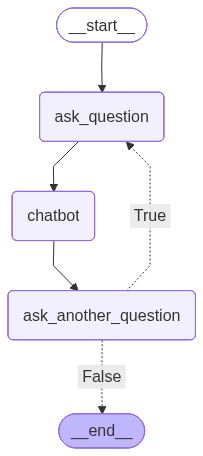

In [85]:
## START -> ASK QUESTION > CHATBOT -> ASK ANOTHER QUESTION ? (YES/NO) 
## YES -> TAKES YOU BACK TO FIRST QUESTION NODE
## NO -> TAKES YOU TO THE END
### define schema of node

#Annotated allows you to attach a reducer function that dictates how to combine the new and old values instead.
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

model = ChatOpenAI(model  ='gpt-5.4-mini', temperature = 0, seed = 100, max_completion_tokens = 100)

#function_node
def chatbot(state: State) -> State:
    print('Entering Chatbot')
    response = model.invoke(state["messages"])
    response.pretty_print()
    return State(messages = [response])
    
def ask_question(state:State) -> State:
    print('Entered ask_question node')
    msg = 'Ask a question: '
    print(msg)
    return State(messages = [AIMessage(msg), HumanMessage(content = input())])

def ask_another_question(state:State) -> State:
    print('Entered ask_another_question node')
    msg = 'Do you have another question (yes/no)?: '
    print(msg)
    return State(messages = [AIMessage(msg), HumanMessage(input())])

def routing_function(state:State) -> str:  ##keep this option as same
    print('***Entered routing_function node with value: ')
    print(*state["messages"],sep='\n')
    if state["messages"][-1].content == "yes":  ##most recent message in the list is the one we are using for determination
        return "True"   #routing function returns true or false
    return "False"
    
graph = StateGraph(State)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("ask_another_question",ask_another_question)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
#to show the graph with conditional nodes printed show method like below - based on what routing function returns the corresponding node is selected
graph.add_conditional_edges(source = "ask_another_question", path = routing_function, path_map = {"True": "ask_question", "False": "__end__"})

graph_compiled = graph.compile()
graph_compiled

In [86]:
graph_compiled.invoke(State(messages=[]))

Entered ask_question node
Ask a question: 


 1+1


Entering Chatbot
================================== Ai Message ==================================

2
Entered ask_another_question node
Do you have another question (yes/no)?: 


 yes


***Entered routing_function node with value: 
content='Ask a question: ' additional_kwargs={} response_metadata={} id='f2fff916-c2ce-453f-a6c3-c36c65cb6e73'
content='1+1' additional_kwargs={} response_metadata={} id='7ed2a809-a467-429f-89b2-c23156f3c5a4'
content='2' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 20, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoK2kIEWOYcGhozVrqotXkFUCt8n1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019ea511-0a36-7300-b80b-927ee9e49a1e-0' usage_metadata={'input_tokens': 20, 'output_tokens': 4, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {

...

 multiply by 6


Entering Chatbot
================================== Ai Message ==================================

24
Entered ask_another_question node
Do you have another question (yes/no)?: 


 no


***Entered routing_function node with value: 
content='Ask a question: ' additional_kwargs={} response_metadata={} id='f2fff916-c2ce-453f-a6c3-c36c65cb6e73'
content='1+1' additional_kwargs={} response_metadata={} id='7ed2a809-a467-429f-89b2-c23156f3c5a4'
content='2' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 20, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoK2kIEWOYcGhozVrqotXkFUCt8n1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019ea511-0a36-7300-b80b-927ee9e49a1e-0' usage_metadata={'input_tokens': 20, 'output_tokens': 4, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {

{'messages': [AIMessage(content='Ask a question: ', additional_kwargs={}, response_metadata={}, id='f2fff916-c2ce-453f-a6c3-c36c65cb6e73'),
  HumanMessage(content='1+1', additional_kwargs={}, response_metadata={}, id='7ed2a809-a467-429f-89b2-c23156f3c5a4'),
  AIMessage(content='2', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 20, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoK2kIEWOYcGhozVrqotXkFUCt8n1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ea511-0a36-7300-b80b-927ee9e49a1e-0', usage_metadata={'input_tokens': 20, 'output_tokens': 4, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outpu

### Get rid of State and use langgraph MessagesState

In [88]:
from langgraph.graph import START,END,add_messages, StateGraph, MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage,BaseMessage
from typing_extensions import TypedDict
from typing import Annotated
from collections.abc import Sequence

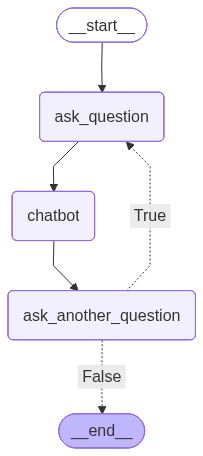

In [89]:
## START -> ASK QUESTION > CHATBOT -> ASK ANOTHER QUESTION ? (YES/NO) 
## YES -> TAKES YOU BACK TO FIRST QUESTION NODE
## NO -> TAKES YOU TO THE END
### define schema of node

#Remvoed State class and use built in MessagesState

model = ChatOpenAI(model  ='gpt-5.4-mini', temperature = 0, seed = 100, max_completion_tokens = 100)

#function_node
def chatbot(state: MessagesState) -> State:
    print('Entering Chatbot')
    response = model.invoke(state["messages"])
    response.pretty_print()
    return MessagesState(messages = [response])
    
def ask_question(state:MessagesState) -> State:
    print('Entered ask_question node')
    msg = 'Ask a question: '
    print(msg)
    return MessagesState(messages = [AIMessage(msg), HumanMessage(content = input())])

def ask_another_question(state:MessagesState) -> State:
    print('Entered ask_another_question node')
    msg = 'Do you have another question (yes/no)?: '
    print(msg)
    return MessagesState(messages = [AIMessage(msg), HumanMessage(input())])

def routing_function(state:MessagesState) -> str:  ##keep this option as same
    print('***Entered routing_function node with value: ')
    print(*state["messages"],sep='\n')
    if state["messages"][-1].content == "yes":  ##most recent message in the list is the one we are using for determination
        return "True"   #routing function returns true or false
    return "False"
    
graph = StateGraph(MessagesState)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("ask_another_question",ask_another_question)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
#to show the graph with conditional nodes printed show method like below - based on what routing function returns the corresponding node is selected
graph.add_conditional_edges(source = "ask_another_question", path = routing_function, path_map = {"True": "ask_question", "False": "__end__"})

graph_compiled = graph.compile()
graph_compiled

In [91]:
graph_compiled.invoke(MessagesState(messages=[]))

Entered ask_question node
Ask a question: 


 1 + 1


Entering Chatbot
================================== Ai Message ==================================

2
Entered ask_another_question node
Do you have another question (yes/no)?: 


 yes


***Entered routing_function node with value: 
content='Ask a question: ' additional_kwargs={} response_metadata={} id='c123c235-85b0-41b3-bf26-0b3ed835729a'
content='1 + 1' additional_kwargs={} response_metadata={} id='ddba1682-98da-465f-9a61-69fb2908fd96'
content='2' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 21, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoKFf5mEGWHdPXt0cHdFRO6tpzBkR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019ea51d-447d-7780-ad0d-914017fe3084-0' usage_metadata={'input_tokens': 21, 'output_tokens': 4, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details':

 add 5 more


Entering Chatbot
================================== Ai Message ==================================

6
Entered ask_another_question node
Do you have another question (yes/no)?: 


 no


***Entered routing_function node with value: 
content='Ask a question: ' additional_kwargs={} response_metadata={} id='c123c235-85b0-41b3-bf26-0b3ed835729a'
content='1 + 1' additional_kwargs={} response_metadata={} id='ddba1682-98da-465f-9a61-69fb2908fd96'
content='2' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 21, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoKFf5mEGWHdPXt0cHdFRO6tpzBkR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019ea51d-447d-7780-ad0d-914017fe3084-0' usage_metadata={'input_tokens': 21, 'output_tokens': 4, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details':

{'messages': [AIMessage(content='Ask a question: ', additional_kwargs={}, response_metadata={}, id='c123c235-85b0-41b3-bf26-0b3ed835729a'),
  HumanMessage(content='1 + 1', additional_kwargs={}, response_metadata={}, id='ddba1682-98da-465f-9a61-69fb2908fd96'),
  AIMessage(content='2', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 21, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoKFf5mEGWHdPXt0cHdFRO6tpzBkR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ea51d-447d-7780-ad0d-914017fe3084-0', usage_metadata={'input_tokens': 21, 'output_tokens': 4, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'out


### Trimming Messages(Keep only last 5 messages in the state list)

In [92]:
from langgraph.graph import START,END,add_messages, StateGraph, MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage,BaseMessage,RemoveMessage
from typing_extensions import TypedDict
from typing import Annotated
from collections.abc import Sequence

In [122]:
#Example
##create message list
my_messages= add_messages([('who is 1'),
    HumanMessage('who is 2') ,
    HumanMessage('who is 3'),
    HumanMessage('who is 4'),
    HumanMessage('who is 5'),
    HumanMessage('who is 6') ,
    HumanMessage('who is 7') ,
    HumanMessage('who is 8') ,
    HumanMessage('who is 9')],
    [HumanMessage('who is 10') ])
my_messages

[HumanMessage(content='who is 1', additional_kwargs={}, response_metadata={}, id='4a2477f7-575d-4bbf-9fc3-dafd793692a2'),
 HumanMessage(content='who is 2', additional_kwargs={}, response_metadata={}, id='05755963-8677-475b-88cc-4ecb68b30d4e'),
 HumanMessage(content='who is 3', additional_kwargs={}, response_metadata={}, id='deff3863-c64d-40ab-821b-8d2f07e44eeb'),
 HumanMessage(content='who is 4', additional_kwargs={}, response_metadata={}, id='c10a6cc2-1ec5-4ad8-9359-eb1f2ba98040'),
 HumanMessage(content='who is 5', additional_kwargs={}, response_metadata={}, id='db0b299f-f153-4cad-9fb5-b3e8d9ff1e28'),
 HumanMessage(content='who is 6', additional_kwargs={}, response_metadata={}, id='68426087-6f89-495d-9c7c-3b0c17c0a87d'),
 HumanMessage(content='who is 7', additional_kwargs={}, response_metadata={}, id='1c0db178-84fb-4259-9d9f-4720d8037591'),
 HumanMessage(content='who is 8', additional_kwargs={}, response_metadata={}, id='9bda4d6f-2bd3-41b9-aece-8e790bd2da47'),
 HumanMessage(content='w

In [123]:
##remove first 7 messages
removed_messages = [RemoveMessage(id=i.id) for i in my_messages[:-3]]
removed_messages

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='4a2477f7-575d-4bbf-9fc3-dafd793692a2'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='05755963-8677-475b-88cc-4ecb68b30d4e'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='deff3863-c64d-40ab-821b-8d2f07e44eeb'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='c10a6cc2-1ec5-4ad8-9359-eb1f2ba98040'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='db0b299f-f153-4cad-9fb5-b3e8d9ff1e28'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='68426087-6f89-495d-9c7c-3b0c17c0a87d'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1c0db178-84fb-4259-9d9f-4720d8037591')]

## invoke add_messages with its original list and removed list. This will cause add_messages to remove what we included in the second list


In [124]:
my_new_messages= add_messages(my_messages,removed_messages)
my_new_messages

[HumanMessage(content='who is 8', additional_kwargs={}, response_metadata={}, id='9bda4d6f-2bd3-41b9-aece-8e790bd2da47'),
 HumanMessage(content='who is 9', additional_kwargs={}, response_metadata={}, id='576e6da3-0eaf-4717-8d8c-d794dd4f3874'),
 HumanMessage(content='who is 10', additional_kwargs={}, response_metadata={}, id='48c0368b-dcc2-4979-a364-852eb0626eb5')]

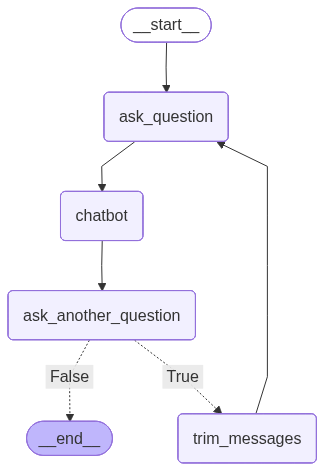

In [105]:
## START -> ASK QUESTION > CHATBOT -> ASK ANOTHER QUESTION ? (YES/NO) 
## YES -> TRIM_MESSAGES >> TAKES YOU BACK TO FIRST QUESTION NODE
## NO -> TAKES YOU TO THE END
### define schema of node

model = ChatOpenAI(model  ='gpt-5.4-mini', temperature = 0, seed = 100, max_completion_tokens = 100)

#function_node
def chatbot(state: MessagesState) -> State:
    print('Entering Chatbot')
    response = model.invoke(state["messages"])
    response.pretty_print()
    return MessagesState(messages = [response])
    
def ask_question(state:MessagesState) -> State:
    print('*** Entered ask_question node *** ')
    for i in state["messages"]:
        print(i.content, i.id)
    print("*****")
    msg = 'Ask a question: '
    print(msg)
    return MessagesState(messages = [AIMessage(msg), HumanMessage(content = input())])

def ask_another_question(state:MessagesState) -> State:
    print('*** Entered ask_another_question node *** ')
    msg = 'Do you have another question (yes/no)?: '
    print(msg)
    return MessagesState(messages = [AIMessage(msg), HumanMessage(input())])

def trim_messages(state:MessagesState) -> State:
    print('*** Entered trim_messages node *** ')
    #remove last 5 messages using RemoveMessage class
    remove_messages = [RemoveMessage(id=i.id) for i in state["messages"][:-5]]
    #print(remove_messages)
    
    for i in remove_messages:
        print(i.id)
    print("*****")
    return MessagesState(messages = remove_messages)
    
def routing_function(state:MessagesState) -> str:  ##keep this option as same
    print('*** Entered routing_function node with value ***')
    #print(*state["messages"],sep='\n')
    for i in state["messages"]:
        print(i.content, i.id)
    print("*****")
    if state["messages"][-1].content == "yes":  ##most recent message in the list is the one we are using for determination
        return "True"   #routing function returns true or false
    return "False"
    
graph = StateGraph(MessagesState)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("ask_another_question",ask_another_question)
graph.add_node("trim_messages",trim_messages)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
#to show the graph with conditional nodes printed show method like below - based on what routing function returns the corresponding node is selected
graph.add_conditional_edges(source = "ask_another_question", path = routing_function, path_map = {"True": "trim_messages", "False": "__end__"})
graph.add_edge("trim_messages", "ask_question")

graph_compiled = graph.compile()
graph_compiled

In [106]:
graph_compiled.invoke(MessagesState(messages=[]))

*** Entered ask_question node *** 
*****
Ask a question: 


 1+1


Entering Chatbot
================================== Ai Message ==================================

2
*** Entered ask_another_question node *** 
Do you have another question (yes/no)?: 


 yes


*** Entered routing_function node with value ***
Ask a question:  4a285b09-96b9-42fe-a734-5d68b93e3298
1+1 e107dc8e-8ddf-4520-adf3-5b399ae1bd13
2 run--019ea81d-78b4-70c0-a369-a852d6ebe54c-0
Do you have another question (yes/no)?:  dc65b817-4b5a-4149-a5a2-0930ba33fdee
yes 5497b92d-55e0-4083-b351-359318fe236c
*****
*** Entered trim_messages node *** 
*****
*** Entered ask_question node *** 
Ask a question:  4a285b09-96b9-42fe-a734-5d68b93e3298
1+1 e107dc8e-8ddf-4520-adf3-5b399ae1bd13
2 run--019ea81d-78b4-70c0-a369-a852d6ebe54c-0
Do you have another question (yes/no)?:  dc65b817-4b5a-4149-a5a2-0930ba33fdee
yes 5497b92d-55e0-4083-b351-359318fe236c
*****
Ask a question: 


...

 3 + 2


Entering Chatbot
================================== Ai Message ==================================

5
*** Entered ask_another_question node *** 
Do you have another question (yes/no)?: 


 no


*** Entered routing_function node with value ***
Ask a question:  7eb50268-c361-4c36-aa41-3a442333ca8f
add 3 df2a21e6-e8cc-41b3-a2a6-0e0578767b84
4 run--019ea81d-e23a-7380-ad77-08fec5fac589-0
Do you have another question (yes/no)?:  7b7b3733-78d9-44c9-8d3f-f19ecb976eaf
yes df0f4f44-4216-4177-8abc-88b838065ea8
Ask a question:  b51685ed-abae-417c-b5da-6e358f1cf968
3 + 2 42787942-240d-4404-9058-300df69c7251
5 run--019ea822-e1a5-7c93-95a5-17a5e53434dc-0
Do you have another question (yes/no)?:  2a6bfb35-24a6-4e72-8a78-327645411482
no ffed9543-24f3-469f-ae3e-07eccde7c5a3
*****


{'messages': [AIMessage(content='Ask a question: ', additional_kwargs={}, response_metadata={}, id='7eb50268-c361-4c36-aa41-3a442333ca8f'),
  HumanMessage(content='add 3', additional_kwargs={}, response_metadata={}, id='df2a21e6-e8cc-41b3-a2a6-0e0578767b84'),
  AIMessage(content='4', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 67, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoXM8wBhh7IsqiQ6ClFigAuMJKkmp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ea81d-e23a-7380-ad77-08fec5fac589-0', usage_metadata={'input_tokens': 67, 'output_tokens': 4, 'total_tokens': 71, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'out

### Summarizing messages

In [136]:
from langgraph.graph import START,END,StateGraph,MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage,RemoveMessage
from typing import Literal

In [137]:
class State(MessagesState):
    summary: str = ""

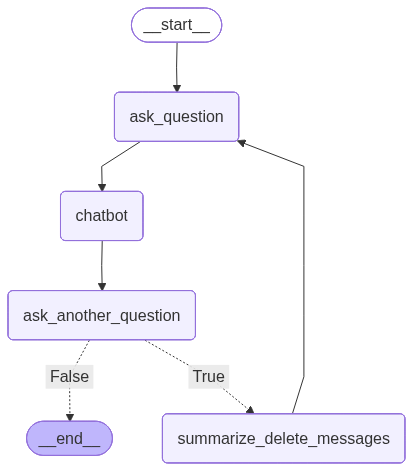

In [184]:
## START -> ASK QUESTION > CHATBOT -> ASK ANOTHER QUESTION ? (YES/NO) 
## YES -> SUMMARIZE_DELETE_MESSAGES >> TAKES YOU BACK TO FIRST QUESTION NODE
## NO -> TAKES YOU TO THE END
### define schema of node

model = ChatOpenAI(model  ='gpt-5.4-mini', temperature = 0, seed = 365, max_completion_tokens = 100)

#function_node
def chatbot(state: State) -> State:
    print('----------Entering Chatbot----------')
    # print("***List of Messages received so far **")
    # for i in state["messages"]:
    #     print(i.content, i.id)
    # print("**End of List of messages ***")
            
    system_message = f'''
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}
    
    Keep this in mind as you answer the next question.
    '''
    print(system_message)
    response = model.invoke([SystemMessage(system_message)] + state["messages"])
    print('*** Response from model: ***')
    response.pretty_print()
    print("*****")
    return State(messages = [response])


def ask_question(state:State) -> State:
    print('---------- Entered ask_question node ----------')
    # print("***List of Messages received so far **")
    # for i in state["messages"]:
    #     print(i.content, i.id)
    # print("**End of List of messages ***")
    msg = 'Ask a question: '
    print(msg)
    return State(messages = [AIMessage(msg), HumanMessage(content = input())])

def ask_another_question(state:State) -> State:
    print('---------- Entered ask_another_question node ---------- ')
    msg = 'Do you have another question (yes/no)?: '
    print(msg)
    return State(messages = [AIMessage(msg), HumanMessage(input())])

def summarize_delete_messages(state:State) -> State:
    print('---------- Entered summarize_delete_messages node ---------- ')
    new_conversation = ''
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"
        
    summary_prompt = f'''
    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repeating it so that the result  
    reflects the most recent context and developments. 
    
    Previous summary: {state.get("summary",'')} 
    
    New Conversation: {new_conversation} 
    '''
    print('Summary prompt for summarizing')
    print(summary_prompt)
    #Remove all "messages"
    remove_messages = [RemoveMessage(id=i.id) for i in state["messages"][:]]
    # print(remove_messages)
    
    # print("***List of Messages received so far **")
    # for i in remove_messages:
    #     print(i.id)
    # print("***End of Remove_Messages **")

    #invoke model to generate summary
    response = model.invoke(summary_prompt)
    # print('*** Response from model: ***')
    # response.pretty_print()
    # print("*****")
    
    return MessagesState(messages = remove_messages, summary = response.content)
    
def routing_function(state:State) -> str:  ##keep this option as same
    print('---------- Entered routing_function node with value ----------')
    # print("***List of Messages received so far **")
    # for i in state["messages"]:
    #     print(i.content, i.id)
    # print("**End of List of messages ***")
    if state["messages"][-1].content == "yes":  ##most recent message in the list is the one we are using for determination
        print('Routing to ask_question')
        return "True"   #routing function returns true or false
    print('Routing to end')
    return "False"
    
graph = StateGraph(State)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("ask_another_question",ask_another_question)
graph.add_node("summarize_delete_messages",summarize_delete_messages)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", path = routing_function, path_map = {"True": "summarize_delete_messages", "False": "__end__"})
graph.add_edge("summarize_delete_messages", "ask_question")
# graph.add_edge(START,"ask_question")
# graph.add_edge("ask_question","chatbot")
# graph.add_edge("chatbot",END)

graph_compiled = graph.compile()
graph_compiled

In [186]:
graph_compiled.invoke(State(messages=[]))

---------- Entered ask_question node ----------
Ask a question: 


 1+1


----------Entering Chatbot----------

    Here's a quick summary of what's been discussed so far:
    
    
    Keep this in mind as you answer the next question.
    
*** Response from model: ***
================================== Ai Message ==================================

2
*****
---------- Entered ask_another_question node ---------- 
Do you have another question (yes/no)?: 


 yes


---------- Entered routing_function node with value ----------
Routing to ask_question
---------- Entered summarize_delete_messages node ---------- 
Summary prompt for summarizing

    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repeating it so that the result  
    reflects the most recent context and developments. 
    
    Previous summary:  
    
    New Conversation: ai: Ask a question: 

human: 1+1

ai: 2

ai: Do you have another question (yes/no)?: 

human: yes

 
    
---------- Entered ask_question node ----------
Ask a question: 


...

 minus 20


----------Entering Chatbot----------

    Here's a quick summary of what's been discussed so far:
    The interaction continues in the same simple arithmetic follow-up pattern. After being prompted to ask a question, the user said “times 5 to the result,” which the AI interpreted as multiplying the previous result by 5 and answered “100 × 5 = 500.” The AI then asked again whether the user has another question (yes/no), and the user replied “yes,” indicating they want to continue with another question.
    
    Keep this in mind as you answer the next question.
    
*** Response from model: ***
================================== Ai Message ==================================

500 - 20 = 480
*****
---------- Entered ask_another_question node ---------- 
Do you have another question (yes/no)?: 


 no


---------- Entered routing_function node with value ----------
Routing to end


{'messages': [AIMessage(content='Ask a question: ', additional_kwargs={}, response_metadata={}, id='202cc1b3-5457-4101-81d3-7f301957da91'),
  HumanMessage(content='minus 20', additional_kwargs={}, response_metadata={}, id='e15d53b3-ede5-42d9-979c-3eead7305321'),
  AIMessage(content='500 - 20 = 480', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 137, 'total_tokens': 147, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DoalvdN0DONhrYRwPaFJIADVGwtIr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ea8e6-4056-7f51-88c4-665ae82611d9-0', usage_metadata={'input_tokens': 137, 'output_tokens': 10, 'total_tokens': 147, 'input_token_details': {'audio': 0, 

## persisting conversation (checkpoints in langgraph)

In [188]:
from langgraph.graph import START,END,StateGraph,MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage,RemoveMessage
from typing import Literal
from langgraph.checkpoint.memory import InMemorySaver

In [191]:
class State(MessagesState):
    summary: str


model = ChatOpenAI(model  ='gpt-5.4-mini', temperature = 0, seed = 365, max_completion_tokens = 100)

#function_node
def chatbot(state: State) -> State:
    print('----------Entering Chatbot----------')            
    system_message = f'''
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}
    
    Keep this in mind as you answer the next question.
    '''
    print(system_message)
    response = model.invoke([SystemMessage(system_message)] + state["messages"])
    print('*** Response from model: ***')
    response.pretty_print()
    print("*****")
    return State(messages = [response])


def ask_question(state:State) -> State:
    print('---------- Entered ask_question node ----------')
    msg = 'Ask a question: '
    print(msg)
    return State(messages = [AIMessage(msg), HumanMessage(content = input())])

def summarize_delete_messages(state:State) -> State:
    print('---------- Entered summarize_delete_messages node ---------- ')
    new_conversation = ''
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"
        
    summary_prompt = f'''
    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repeating it so that the result  
    reflects the most recent context and developments. 
    
    Previous summary: {state.get("summary",'')} 
    
    New Conversation: {new_conversation} 
    '''
    print('Summary prompt for summarizing')
    print(summary_prompt)
    #Remove all "messages"
    remove_messages = [RemoveMessage(id=i.id) for i in state["messages"][:]]

    #invoke model to generate summary
    response = model.invoke(summary_prompt)    
    return MessagesState(messages = remove_messages, summary = response.content)
    
    
graph = StateGraph(State)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("summarize_delete_messages",summarize_delete_messages)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "summarize_delete_messages")
graph.add_edge("summarize_delete_messages", END)



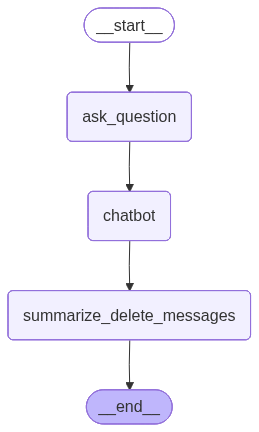

In [204]:
checkpoint = InMemorySaver()

graph_compiled = graph.compile(checkpoint)
graph_compiled    

In [205]:
thread1 = {"configurable": {"thread_id": "1"}}
thread2 = {"configurable": {"thread_id": "2"}}

In [206]:
graph_compiled.invoke(State(),thread1)          

---------- Entered ask_question node ----------
Ask a question: 


 what is the care needed for snake plant?


----------Entering Chatbot----------

    Here's a quick summary of what's been discussed so far:
    
    
    Keep this in mind as you answer the next question.
    
*** Response from model: ***
================================== Ai Message ==================================

Snake plant care is fairly easy:

- **Light:** Low to bright indirect light; tolerates some direct sun.
- **Water:** Water only when the soil is completely dry. In winter, even less often.
- **Soil:** Well-draining cactus/succulent mix.
- **Pot:** Use a pot with drainage holes.
- **Temperature:** Normal indoor temps, ideally 60–85°F (15–29°C).
- **Fertilizer:** Light feeding in
*****
---------- Entered summarize_delete_messages node ---------- 
Summary prompt for summarizing

    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repeating it so that the result  
    reflects the most recent context and developments. 
    
    Previo

{'messages': [],
 'summary': 'The conversation shifted to a houseplant care question. The user asked what care a snake plant needs, and the assistant began outlining basic care: low to bright indirect light, infrequent watering only after the soil fully dries, well-draining soil, a pot with drainage holes, normal indoor temperatures, and light fertilizer in the growing season. The response was cut off mid-sentence at the fertilizer point, so the guidance is currently incomplete.'}

In [207]:
graph_compiled.invoke(State(),thread1)          

---------- Entered ask_question node ----------
Ask a question: 


 how tall do they grow ?


----------Entering Chatbot----------

    Here's a quick summary of what's been discussed so far:
    The conversation shifted to a houseplant care question. The user asked what care a snake plant needs, and the assistant began outlining basic care: low to bright indirect light, infrequent watering only after the soil fully dries, well-draining soil, a pot with drainage holes, normal indoor temperatures, and light fertilizer in the growing season. The response was cut off mid-sentence at the fertilizer point, so the guidance is currently incomplete.
    
    Keep this in mind as you answer the next question.
    
*** Response from model: ***
================================== Ai Message ==================================

Snake plants usually grow about **1 to 4 feet tall** indoors, depending on the variety and growing conditions.

- **Common types**: often around **2 to 3 feet**
- **Larger varieties**: can reach **4 to 6 feet** indoors
- **In their native habitat**: some can grow even

{'messages': [],
 'summary': 'The conversation continued with the user asking how tall snake plants grow. The assistant answered that they typically reach about **1 to 4 feet tall indoors**, with common varieties usually around **2 to 3 feet** and larger types sometimes reaching **4 to 6 feet** indoors. It also noted that plants in their native habitat can grow taller, and offered to explain which varieties stay small versus grow very tall.'}

In [208]:
graph_compiled.invoke(State(),thread2)          

---------- Entered ask_question node ----------
Ask a question: 


 are these indoor or outdoor plants ?


----------Entering Chatbot----------

    Here's a quick summary of what's been discussed so far:
    
    
    Keep this in mind as you answer the next question.
    
*** Response from model: ***
================================== Ai Message ==================================

I can help, but I need to know which plants you mean.

Please send:
- a photo, or
- the plant names

and I’ll tell you whether they’re indoor, outdoor, or can do both.
*****
---------- Entered summarize_delete_messages node ---------- 
Summary prompt for summarizing

    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repeating it so that the result  
    reflects the most recent context and developments. 
    
    Previous summary:  
    
    New Conversation: ai: Ask a question: 

human: are these indoor or outdoor plants ?

ai: I can help, but I need to know which plants you mean.

Please send:
- a photo, or
- the plant names



{'messages': [],
 'summary': 'The conversation is about identifying whether specific plants are indoor or outdoor plants. The assistant asked for either a photo or the plant names so it can determine whether they are indoor, outdoor, or suitable for both environments.'}

## Long term memory with SQLite

In [4]:
from langgraph.graph import START,END,StateGraph,MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage,RemoveMessage
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

/opt/anaconda3/envs/langgraph_env/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
class State(MessagesState):
    summary: str


model = ChatOpenAI(model  ='gpt-5.4-mini', temperature = 0, seed = 365, max_completion_tokens = 100)

#function_node
def chatbot(state: State) -> State:
    print('----------Entering Chatbot----------')            
    system_message = f'''
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}
    
    Keep this in mind as you answer the next question.
    '''
    print(system_message)
    response = model.invoke([SystemMessage(system_message)] + state["messages"])
    print('*** Response from model: ***')
    response.pretty_print()
    print("*****")
    return State(messages = [response])


def ask_question(state:State) -> State:
    print('---------- Entered ask_question node ----------')
    msg = 'Ask a question: '
    print(msg)
    return State(messages = [AIMessage(msg), HumanMessage(content = input())])

def summarize_delete_messages(state:State) -> State:
    print('---------- Entered summarize_delete_messages node ---------- ')
    new_conversation = ''
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"
        
    summary_prompt = f'''
    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repeating it so that the result  
    reflects the most recent context and developments. 
    
    Previous summary: {state.get("summary",'')} 
    
    New Conversation: {new_conversation} 
    '''
    print('Summary prompt for summarizing')
    print(summary_prompt)
    #Remove all "messages"
    remove_messages = [RemoveMessage(id=i.id) for i in state["messages"][:]]

    #invoke model to generate summary
    response = model.invoke(summary_prompt)    
    return MessagesState(messages = remove_messages, summary = response.content)
    
    
graph = StateGraph(State)
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("summarize_delete_messages",summarize_delete_messages)

graph.add_edge(START,"ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "summarize_delete_messages")
graph.add_edge("summarize_delete_messages", END)

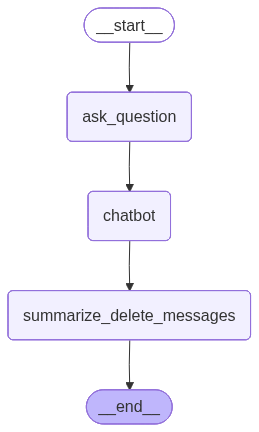

In [6]:
db_path = "langgraph.db"
con = sqlite3.connect(database = db_path, check_same_thread = False)
checkpoint = SqliteSaver(con)

graph_compiled = graph.compile(checkpoint)
graph_compiled    

In [7]:
thread3 = {"configurable": {"thread_id": "3"}}
thread4 = {"configurable": {"thread_id": "4"}}

In [215]:
graph_compiled.invoke(State(),thread3)

---------- Entered ask_question node ----------
Ask a question: 


 who is madam curie?


----------Entering Chatbot----------

    Here's a quick summary of what's been discussed so far:
    
    
    Keep this in mind as you answer the next question.
    
*** Response from model: ***
================================== Ai Message ==================================

Madam Curie usually refers to **Marie Curie** (1867–1934), the Polish-French physicist and chemist.

She was famous for:
- **Discovering the elements polonium and radium**
- **Pioneering research on radioactivity** — a term she helped popularize
- **Winning two Nobel Prizes**:
  - **Physics** (1903)
  - **Chemistry** (1911)

She was the first woman
*****
---------- Entered summarize_delete_messages node ---------- 
Summary prompt for summarizing

    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repeating it so that the result  
    reflects the most recent context and developments. 
    
    Previous summary:  
    
    New Con

{'messages': [],
 'summary': 'The conversation began with the assistant prompting the user to ask a question. The user then asked, “who is madam curie?” The assistant answered that Madam Curie usually refers to **Marie Curie** (1867–1934), the Polish-French physicist and chemist. It described her as a pioneer in **radioactivity**, noted her discovery of **polonium and radium**, and mentioned that she won **two Nobel Prizes**: **Physics in '}

In [8]:
graph_compiled.invoke(State(),thread3)

---------- Entered ask_question node ----------
Ask a question: 


 where was she born ?


----------Entering Chatbot----------

    Here's a quick summary of what's been discussed so far:
    The conversation began with the assistant prompting the user to ask a question. The user then asked, “who is madam curie?” The assistant answered that Madam Curie usually refers to **Marie Curie** (1867–1934), the Polish-French physicist and chemist. It described her as a pioneer in **radioactivity**, noted her discovery of **polonium and radium**, and mentioned that she won **two Nobel Prizes**: **Physics in 
    
    Keep this in mind as you answer the next question.
    
*** Response from model: ***
================================== Ai Message ==================================

Marie Curie was born in **Warsaw, Poland** on **November 7, 1867**.
*****
---------- Entered summarize_delete_messages node ---------- 
Summary prompt for summarizing

    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repea

{'messages': [],
 'summary': 'The conversation continued with the user asking where Marie Curie was born. The assistant replied that Marie Curie was born in **Warsaw, Poland** on **November 7, 1867**.'}

In [9]:
graph_compiled.invoke(State(),thread4)

---------- Entered ask_question node ----------
Ask a question: 


 what was she famous for ?


----------Entering Chatbot----------

    Here's a quick summary of what's been discussed so far:
    
    
    Keep this in mind as you answer the next question.
    
*** Response from model: ***
================================== Ai Message ==================================

I’m missing the context for who “she” refers to. Could you tell me her name or the person/article you mean?
*****
---------- Entered summarize_delete_messages node ---------- 
Summary prompt for summarizing

    Update the ongoing summary by incorporating the new lines of conversation below.  
    Build upon the previous summary rather than repeating it so that the result  
    reflects the most recent context and developments. 
    
    Previous summary:  
    
    New Conversation: ai: Ask a question: 

human: what was she famous for ?

ai: I’m missing the context for who “she” refers to. Could you tell me her name or the person/article you mean?

 
    


{'messages': [],
 'summary': 'The conversation so far is a brief clarification exchange. The user asked, “what was she famous for?” and the assistant responded that it needs more context to identify who “she” refers to, asking for her name or the relevant person/article.'}